In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json 
from matplotlib_venn import venn2
import itertools
import mpltern

import warnings

# Suppress warnings
warnings.simplefilter(action='ignore', category=Warning)

fsize = 15
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'

In [60]:
pd.read_json("../../data/adipose_Emont2022/evidence_deg/evidence_unfiltered_metrics.json")["source"].apply(pd.Series)["source_metrics"].apply(pd.Series)

,p_corr,log_fc,nnz_frac_i,nnz_frac_o
0,0.0,3.699825,0.426,0.082
1,0.0,3.668332,0.867,0.247
2,0.0,3.565394,0.960,0.506
3,0.0,3.417902,0.829,0.266
4,0.0,3.383653,0.493,0.120
...,...,...,...,...
32638,1.0,0.535100,0.220,0.100
32639,1.0,0.722357,0.171,0.072
32640,1.0,0.670608,0.317,0.172
32641,1.0,0.550749,0.463,0.300


In [68]:
def load_evidence(fn, ds_name, metrics=False):
    # we only want derived since we're going to compare gene ids
    df = pd.read_json(fn)
    df["ds_name"] = ds_name
    ddf = df['derived'].apply(pd.Series)


    # normalize the string values for cell types
    ddf["cell_type_label"] = ddf["cell_type_label"].str.strip().str.upper()
    ddf["cell_type_id"] = ddf["cell_type_id"].str.strip().str.upper()
    
    # normalize the string values for genes
    ddf["feature_name"] = ddf["feature_name"].str.strip().str.upper()
    ddf["feature_identifier"] = ddf["feature_identifier"].str.strip().str.upper()

    if metrics:
        metrics = df["source"].apply(pd.Series)["source_metrics"].apply(pd.Series)
        ddf = pd.concat([ddf, metrics], axis=1)

    hddf = ddf.query("organism == 'homo_sapiens'").dropna(subset=["feature_identifier"])
    return hddf

def set_itx(a, b, vals=False):
    itx = np.intersect1d(a, b)
    if vals:
        return itx
    return itx.shape[0]

def set_diff(a, b, vals=False):
    diff = np.setdiff1d(a, b)
    if vals:
        return diff
    return diff.shape[0]

def set_cmp(a,b, vals=False):
    return (set_diff(a,b,vals), set_itx(a,b,vals), set_diff(b,a,vals))

def get_ctmap(ctmap_fn):
    with open(ctmap_fn, 'r') as file:
        map_dict = json.load(file)
        upper_map = {k.upper(): [v.upper() for v in vals] for k, vals in map_dict.items()}
        rev_map = {v: k for k, vals in upper_map.items() for v in vals}
    return (upper_map, rev_map)

In [69]:
# ds = "adipose_Hildreth2021"
# ds = "adipose_Vijay2019"

# ds = "adipose_Hildreth2021"
ds = "adipose_Emont2022"
fn_hmn   = f"../../data/{ds}/evidence_human/evidence.json"
fn_deg   = f"../../data/{ds}/evidence_deg/evidence_unfiltered_metrics.json"
ctmap_fn = f"../../data/{ds}/ctmap/ctmap.json"

hmn = load_evidence(fn_hmn, ds)
deg = load_evidence(fn_deg, ds, metrics=True)
ctmap, rev_ctmap = get_ctmap(ctmap_fn)

hmn["cell_type_id"] = hmn["cell_type_label"].map(lambda x: rev_ctmap[x])
deg["cell_type_id"] = deg["cell_type_label"].map(lambda x: rev_ctmap[x])

## Global Gene and Celltype comparisons

In [71]:
feature = "feature_identifier" # <-- to use once we fill in the id from the gene name
# feature = "feature_name"

hmn_features = pd.Series(hmn[feature].unique()).dropna().tolist()
deg_features = pd.Series(deg[feature].unique()).dropna().tolist()

l, x, r  = set_cmp(hmn_features, deg_features)                # raw counts
nl, nx, nr = np.array([l,x,r]) / np.array([l,x,r]).sum()      # normalized counts
lv, xv, rv  = set_cmp(hmn_features, deg_features, vals=True)  # actual lists

gene_vals = [l,x,r]
gene_nvals = [nl,nx,nr]

print(f"Human v DEG ({feature})")
print("\tleft\titx\tright")
print(f"raw\t{l}\t{x}\t{r}")
print(f"norm\t{nl:.2f}\t{nx:.2f}\t{nr:.2f}")

Human v DEG (feature_identifier)
	left	itx	right
raw	5	99	8150
norm	0.00	0.01	0.99


In [72]:
# feature = "cell_type_label" # eventually change this to comparing based on a map we can create
feature = "cell_type_id"

hmn_features = pd.Series(hmn[feature].unique()).dropna().tolist()
deg_features = pd.Series(deg[feature].unique()).dropna().tolist()

l, x, r  = set_cmp(hmn_features, deg_features)               # raw counts
nl, nx, nr = np.array([l,x,r]) / np.array([l,x,r]).sum()     # normalized counts
lv, xv, rv  = set_cmp(hmn_features, deg_features, vals=True) # actual lists

ct_vals = [l,x,r]
ct_nvals = [nl,nx,nr]

print(f"Human v DEG ({feature})")
print("\tleft\titx\tright")
print(f"raw\t{l}\t{x}\t{r}")
print(f"norm\t{nl:.2f}\t{nx:.2f}\t{nr:.2f}")

Human v DEG (cell_type_id)
	left	itx	right
raw	0	15	1
norm	0.00	0.94	0.06


In [73]:
# Define the multi-level column structure and data
columns = pd.MultiIndex.from_product(
    [["cell_type_id", "feature_name"], ["left", "itx", "right"]],
    names=["Feature", "Set Comparison"]
)

data = [
    ct_vals +  gene_vals,  # raw values
   ct_nvals + gene_nvals  # normalized values
]

# Create the DataFrame
df = pd.DataFrame(data, columns=columns, index=["raw", "norm"])



In [74]:
df

Feature        cell_type_id                  feature_name             \
Set Comparison         left      itx   right         left        itx   
raw                     0.0  15.0000  1.0000     5.000000  99.000000   
norm                    0.0   0.9375  0.0625     0.000606   0.011994   

Feature                    
Set Comparison      right  
raw             8150.0000  
norm               0.9874

## Cell-type-specific comparisons

In [90]:
def ctg_metric(df1, df2, gene_col = "feature_name", ct_col = "cell_type_label", df1_label="hmn", df2_label="deg", comm_ct=True, comm_gene=True, vals=False):
    # common cell types
    common_ct = np.intersect1d(df1[ct_col].unique(), df2[ct_col].unique())
    common_gn = np.intersect1d(df1[gene_col].unique(), df2[gene_col].unique())


    # comm_df1 = df1[df1[ct_col].isin(common_ct)]
    # comm_df2 = df2[df2[ct_col].isin(common_ct)]
    
    # here we filter for the same set of cell types and genes <-- note we may want to change this!
    if comm_ct and not comm_gene:
        comm_df1 = df1[df1[ct_col].isin(common_ct)]
        comm_df2 = df2[df2[ct_col].isin(common_ct)]
    elif comm_gene and not comm_ct:
        comm_df1 = df1[df1[gene_col].isin(common_gn)]
        comm_df2 = df2[df2[gene_col].isin(common_gn)]
    elif comm_ct and comm_gene:
        comm_df1 = df1[df1[ct_col].isin(common_ct) & df1[gene_col].isin(common_gn)]
        comm_df2 = df2[df2[ct_col].isin(common_ct) & df2[gene_col].isin(common_gn)]
    else:
        comm_df1 = df1
        comm_df2 = df2

    df1_ctg_list = comm_df1.groupby(ct_col)[gene_col].apply(lambda x: x.unique())
    if comm_ct:
        df1_ctg_list = df1_ctg_list.reindex(common_ct, fill_value=[])
    df2_ctg_list = comm_df2.groupby(ct_col)[gene_col].apply(lambda x: x.unique())
    if comm_ct:
        df2_ctg_list = df2_ctg_list.reindex(common_ct, fill_value=[])

    # now take the left set diff, intersection, and right set diff for every pair of cell types in the two dataframes
    ctg_cmp = {}
    ctg_cmp_vals = {}
    for ct1 in df1_ctg_list.index:
        for ct2 in df2_ctg_list.index:
            l, x, r  = set_cmp(df1_ctg_list[ct1], df2_ctg_list[ct2])
            lv, xv, rv  = set_cmp(df1_ctg_list[ct1], df2_ctg_list[ct2], vals=True)
            ctg_cmp[(ct1, ct2)] = (l, x, r)
            ctg_cmp_vals[(ct1, ct1)] = (lv, xv, rv)

    if vals:
        return ctg_cmp_vals
    
    pvt = pd.DataFrame(ctg_cmp.values(), index=ctg_cmp.keys(), columns=["l", "x", "r"]).reset_index(names=[df1_label, df2_label]).pivot(index=df1_label, columns=df2_label, values=["l", "x", "r"]).fillna(0)

    df1_ct = pvt.index
    df2_ct = pvt.columns.levels[1]
    mtx = pvt.to_numpy().reshape(len(df1_ct), 3, len(df2_ct))
    norm_mtx = mtx / mtx.sum(axis=1)[:, np.newaxis, :]
    mtx = mtx.transpose(0,2,1)
    norm_mtx = norm_mtx.transpose(0,2,1)
    return (mtx, norm_mtx, df1_ct, df2_ct)

## All "OG" cell type names between human and DEG

In [85]:
deg["feature_identifier"].isna().sum(), hmn["feature_identifier"].isna().sum()

(np.int64(0), np.int64(0))

In [77]:
(mtx, norm_mtx, hmnct, degct) = ctg_metric(hmn, deg, gene_col = "feature_identifier", ct_col = "cell_type_id", 
df1_label="hmn", df2_label="deg", comm_ct=False, comm_gene=True)
df = pd.DataFrame(mtx.tolist(), index=hmnct, columns=degct)
df.head()

deg,ADIPOCYTE,B CELL,DENDRITIC CELL,ENDOMETRIUM,ENDOTHELIUM,HUMAN ASPCS,MACROPHAGE,MAST_CELL,MESOTHELIUM,MONOCYTE,NATURAL KILLER CELL,NEUTROPHIL,PERICYTE,PLASMABLAST,SMOOTH MUSCLE CELLS,T CELL
hmn,,,,,,,,,,,,,,,,
ADIPOCYTE,"[19, 38, 5]","[50, 7, 6]","[43, 14, 10]","[54, 3, 3]","[45, 12, 9]","[44, 13, 8]","[41, 16, 13]","[52, 5, 4]","[47, 10, 13]","[42, 15, 7]","[49, 8, 2]","[46, 11, 3]","[49, 8, 2]","[55, 2, 1]","[50, 7, 7]","[48, 9, 6]"
B CELL,"[2, 0, 43]","[0, 2, 11]","[1, 1, 23]","[2, 0, 6]","[2, 0, 21]","[2, 0, 21]","[1, 1, 28]","[1, 1, 8]","[2, 0, 23]","[1, 1, 21]","[1, 1, 9]","[1, 1, 13]","[2, 0, 10]","[2, 0, 3]","[2, 0, 14]","[1, 1, 14]"
DENDRITIC CELL,"[4, 0, 43]","[3, 1, 12]","[0, 4, 20]","[4, 0, 6]","[4, 0, 21]","[4, 0, 21]","[2, 2, 27]","[3, 1, 8]","[4, 0, 23]","[2, 2, 20]","[3, 1, 9]","[3, 1, 13]","[4, 0, 10]","[4, 0, 3]","[4, 0, 14]","[3, 1, 14]"
ENDOTHELIUM,"[8, 1, 42]","[7, 2, 11]","[7, 2, 22]","[9, 0, 6]","[2, 7, 14]","[8, 1, 20]","[5, 4, 25]","[8, 1, 8]","[6, 3, 20]","[7, 2, 20]","[9, 0, 10]","[8, 1, 13]","[9, 0, 10]","[9, 0, 3]","[8, 1, 13]","[8, 1, 14]"
HUMAN ASPCS,"[6, 1, 42]","[6, 1, 12]","[6, 1, 23]","[6, 1, 5]","[6, 1, 20]","[2, 5, 16]","[6, 1, 28]","[7, 0, 9]","[4, 3, 20]","[6, 1, 21]","[7, 0, 10]","[7, 0, 14]","[6, 1, 9]","[7, 0, 3]","[6, 1, 13]","[7, 0, 15]"


# All consistent Cell Types

In [88]:
(mtx, norm_mtx, hmnct, degct) = ctg_metric(hmn, deg, gene_col = "feature_identifier", ct_col = "cell_type_id", df1_label="hmn", df2_label="deg", comm_ct=True, comm_gene=True, vals=True)

df = pd.DataFrame(mtx.tolist(), index=hmnct, columns=degct)
df.head()

deg,ADIPOCYTE,B CELL,DENDRITIC CELL,ENDOTHELIUM,HUMAN ASPCS,MACROPHAGE,MAST_CELL,MESOTHELIUM,MONOCYTE,NATURAL KILLER CELL,NEUTROPHIL,PERICYTE,PLASMABLAST,SMOOTH MUSCLE CELLS,T CELL
hmn,,,,,,,,,,,,,,,
ADIPOCYTE,"[[ENSG00000011198, ENSG00000019582, ENSG000000...","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]"
B CELL,"[0, 0, 0]","[[ENSG00000156738], [ENSG00000081237], [ENSG00...","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]"
DENDRITIC CELL,"[0, 0, 0]","[0, 0, 0]","[[ENSG00000132514, ENSG00000197992, ENSG000001...","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]"
ENDOTHELIUM,"[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[[ENSG00000013297, ENSG00000106852, ENSG000001...","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]"
HUMAN ASPCS,"[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[[ENSG00000044524, ENSG00000070193, ENSG000001...","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]"


In [ ]:
vals = ctg_metric(hmn, deg, gene_col = "feature_identifier", ct_col = "cell_type_id", df1_label="hmn", df2_label="deg", comm_ct=True, comm_gene=True, vals=True)
comm = pd.DataFrame(vals.values(), index=vals.keys(), columns=["l", "x", "r"]).reset_index(names=["hmn", "deg"]).query("hmn==deg").set_index(["hmn"])["x"].explode().dropna()

discussed = deg[deg.apply(lambda row: (row["cell_type_id"], row["feature_identifier"]) in set(comm.items()), axis=1)].drop_duplicates(["cell_type_id", "feature_identifier"])
not_discussed = deg.query("p_corr < 0.01").groupby("cell_type_id").apply(lambda x: x.nlargest(5, "log_fc")).reset_index(drop=True)

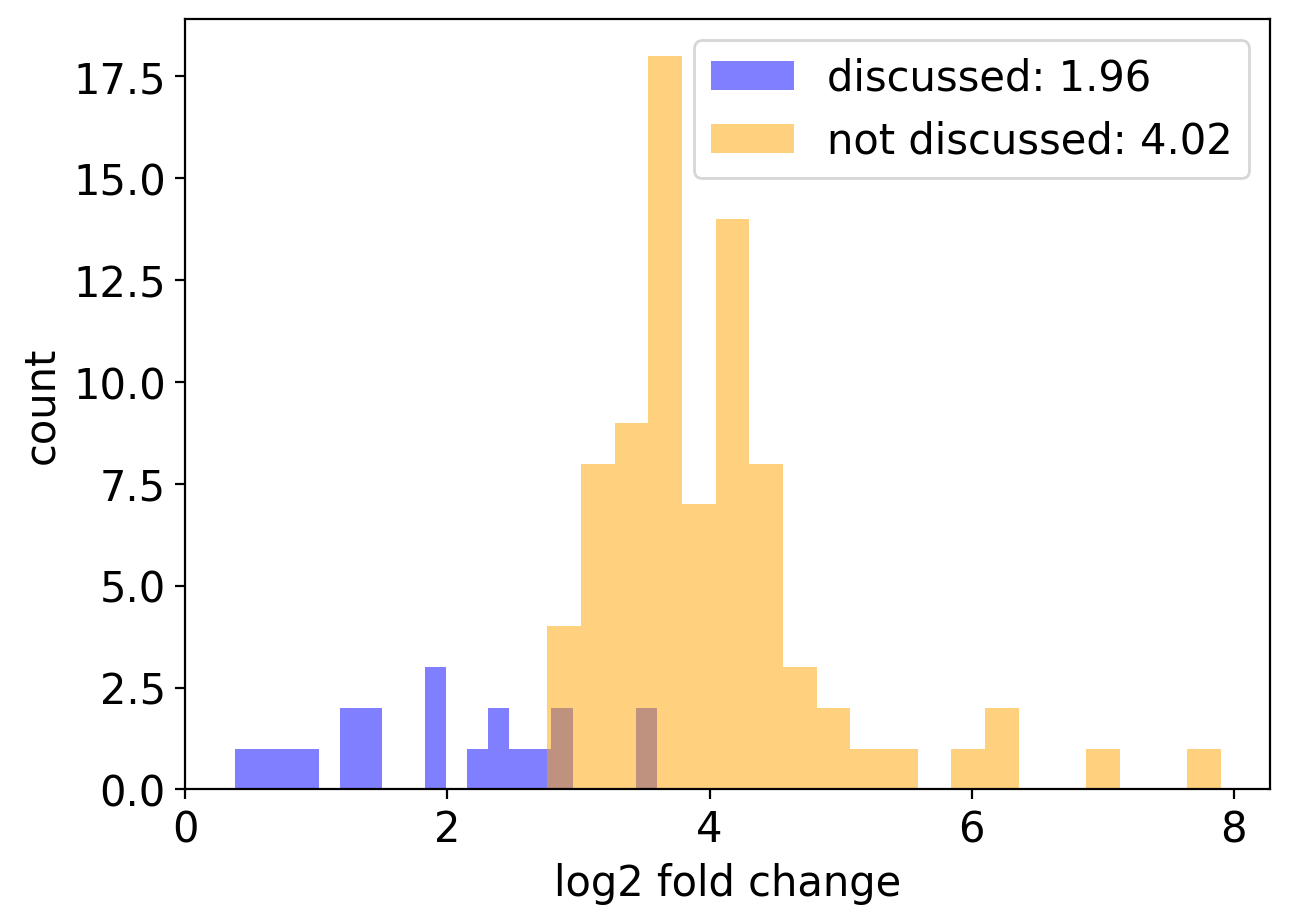

In [145]:
fig, ax = plt.subplots(figsize=(7, 5))

x = discussed["log_fc"]
mean = np.mean(x)
ax.hist(x, bins=20, alpha=0.5, color="blue", label=f"discussed: {mean:.2f}")


x = not_discussed["log_fc"]

mean = np.mean(x)
ax.hist(x, bins=20, alpha=0.5, color="orange", label=f"not discussed: {mean:.2f}")

ax.set(**{
    "xlabel": "log2 fold change",
    "ylabel": "count",

})
ax.legend()
plt.show()

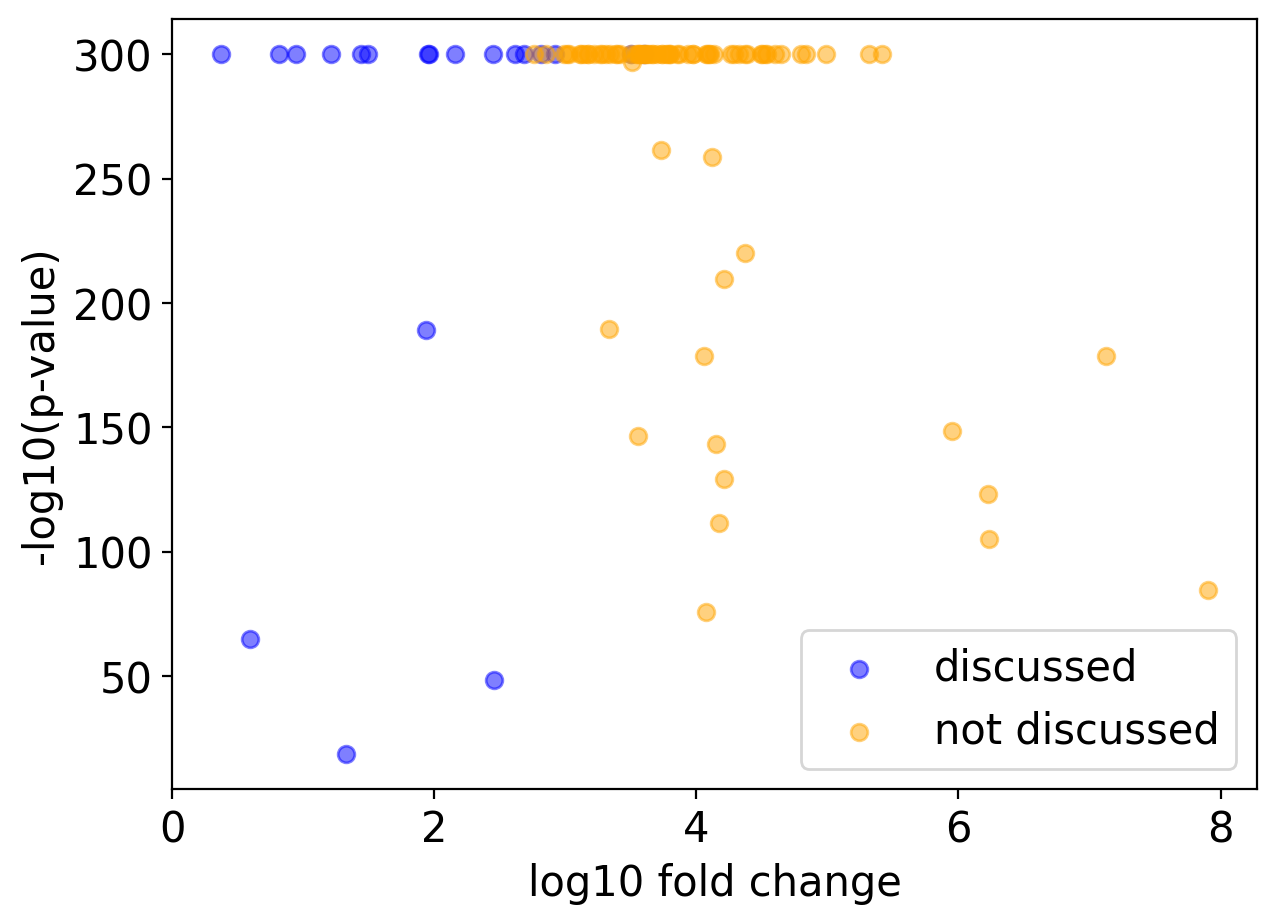

In [154]:
import numpy as np
import matplotlib.pyplot as plt

# Define a very small number to replace zeros
min_pval = 1e-300

# Replace zeros in the p-values with the minimum p-value
discussed_p = discussed["p_corr"].replace(0, min_pval)
not_discussed_p = not_discussed["p_corr"].replace(0, min_pval)

fig, ax = plt.subplots(figsize=(7, 5))

# Use np.log10 for a volcano plot (-log10(p))
x_discussed = discussed["log_fc"]
y_discussed = -np.log10(discussed_p)
ax.scatter(x_discussed, y_discussed, alpha=0.5, color="blue", label="discussed")

x_not_discussed = not_discussed["log_fc"]
y_not_discussed = -np.log10(not_discussed_p)
ax.scatter(x_not_discussed, y_not_discussed, alpha=0.5, color="orange", label="not discussed")

ax.set(xlabel="log10 fold change", ylabel="-log10(p-value)")
ax.legend()
plt.show()

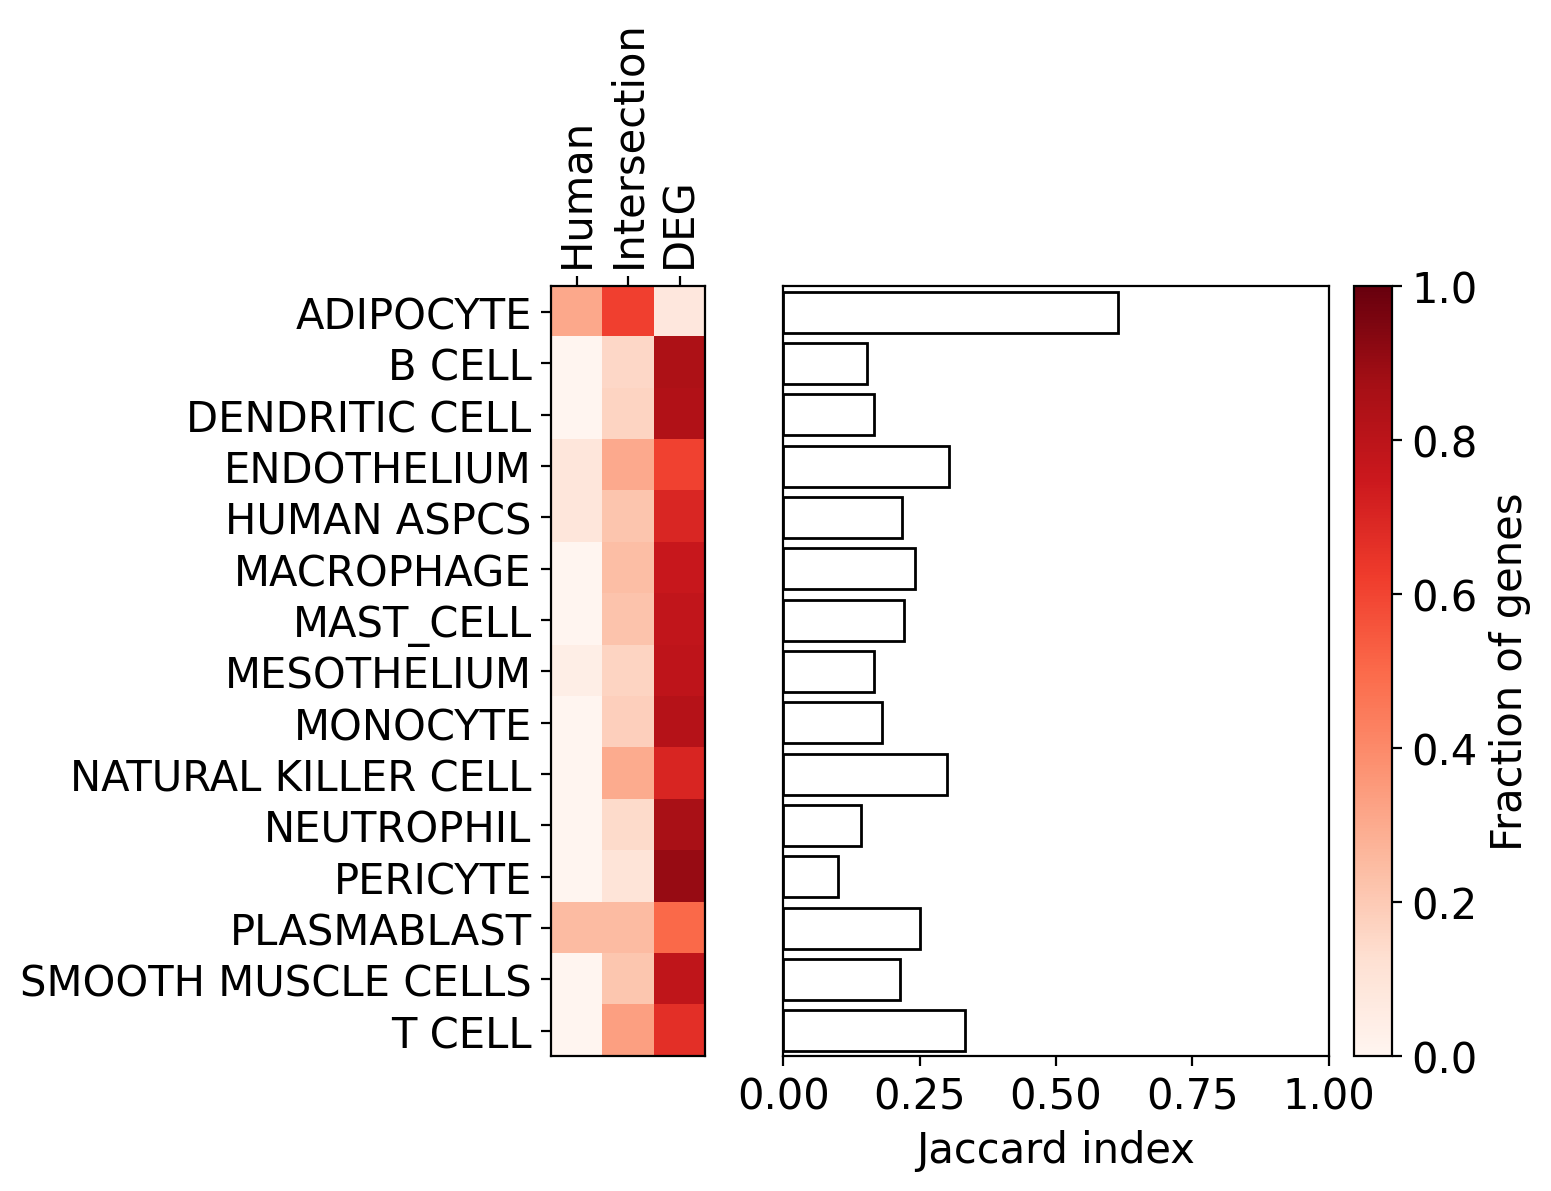

In [79]:
fig, axs = plt.subplots(figsize=(7, 5), ncols=2)
fig.subplots_adjust(hspace=0, wspace=-0.25)

ax = axs[0]
xlabels = ["Human", "Intersection", "DEG"]
eye = norm_mtx[np.eye(norm_mtx.shape[0], dtype=bool)]

cax = ax.imshow(eye, cmap="Reds", vmin=0, vmax=1)

ax.set(**{
    "xticks": np.arange(len(xlabels)),
    "yticks": np.arange(len(hmnct)),
    "xticklabels": xlabels,
    "yticklabels": hmnct,
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')  # Set the label position at the top

ax = axs[1]
eye = norm_mtx[np.eye(norm_mtx.shape[0], dtype=bool)]
jac = eye[:,1] / (eye[:,0] + eye[:,2] + eye[:,1])
jac = jac[::-1]

ax.barh(np.arange(len(hmnct)), jac, edgecolor="black", facecolor="white")
ax.set(**{
    "yticks": np.arange(len(hmnct)),
    "yticklabels": [],
    "xlabel": "Jaccard index",
    # "title": "Jaccard index",
    "xlim": (0,1),
    "ylim": (-0.5, len(hmnct)-0.5)
})
ax.yaxis.set_visible(False)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, horizontalalignment='right')
plt.colorbar(cax, ax=ax, fraction=0.08, pad=0.04, label="Fraction of genes")

plt.show()


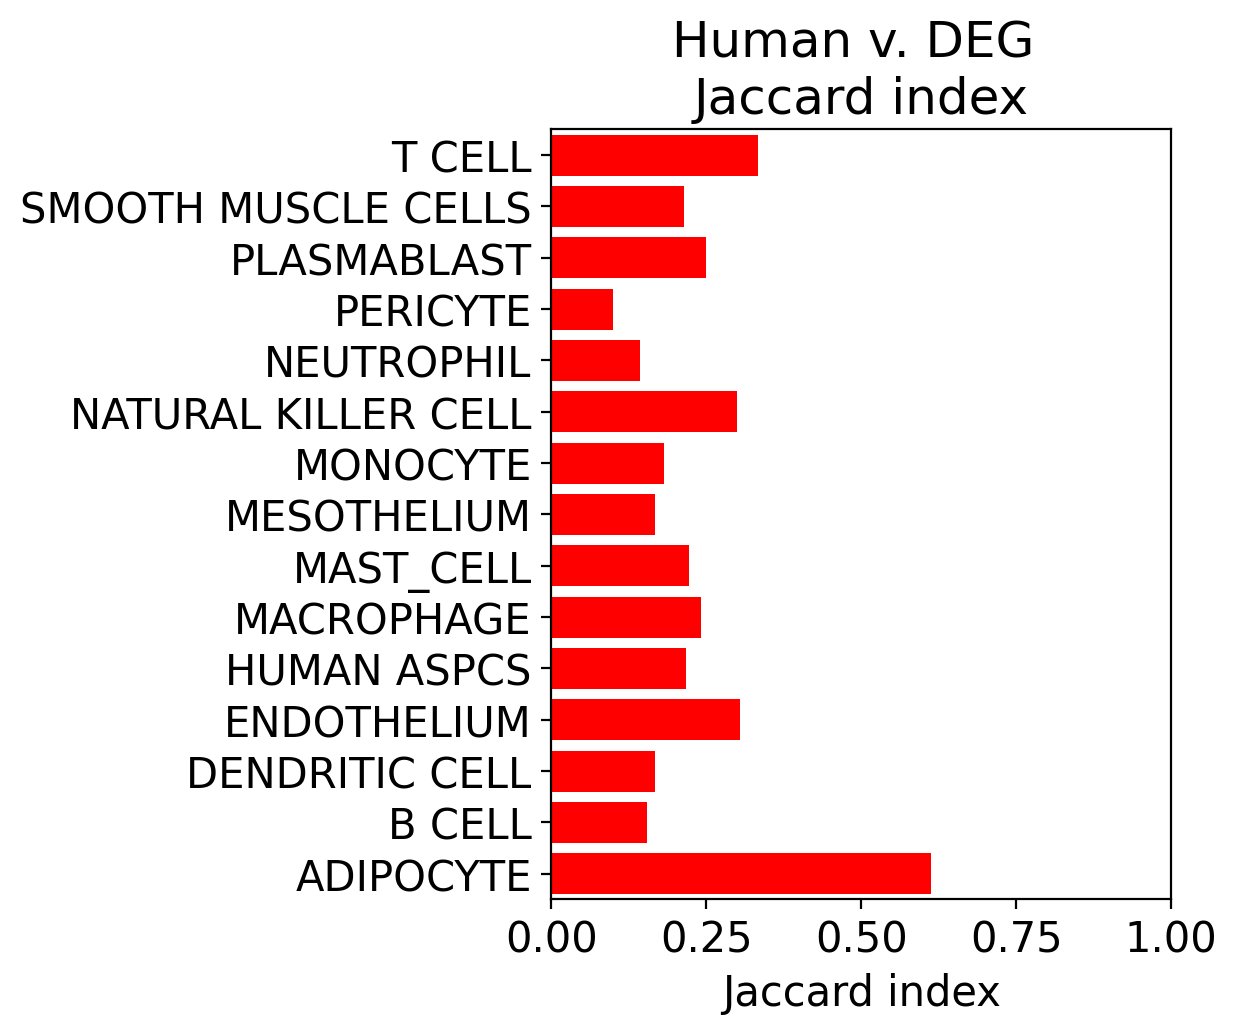

In [80]:
fig, ax = plt.subplots(figsize=(4, 5))

eye = norm_mtx[np.eye(norm_mtx.shape[0], dtype=bool)]
jac = eye[:,1] / (eye[:,0] + eye[:,2] + eye[:,1])

ax.barh(np.arange(len(hmnct)), jac, color="red")
ax.set(**{
    "yticks": np.arange(len(hmnct)),
    "yticklabels": hmnct,
    "xlabel": "Jaccard index",
    "title": "Human v. DEG \nJaccard index",
    "xlim": (0,1),
    "ylim": (-0.5, len(hmnct)-0.5)
})
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, horizontalalignment='right')
plt.show()


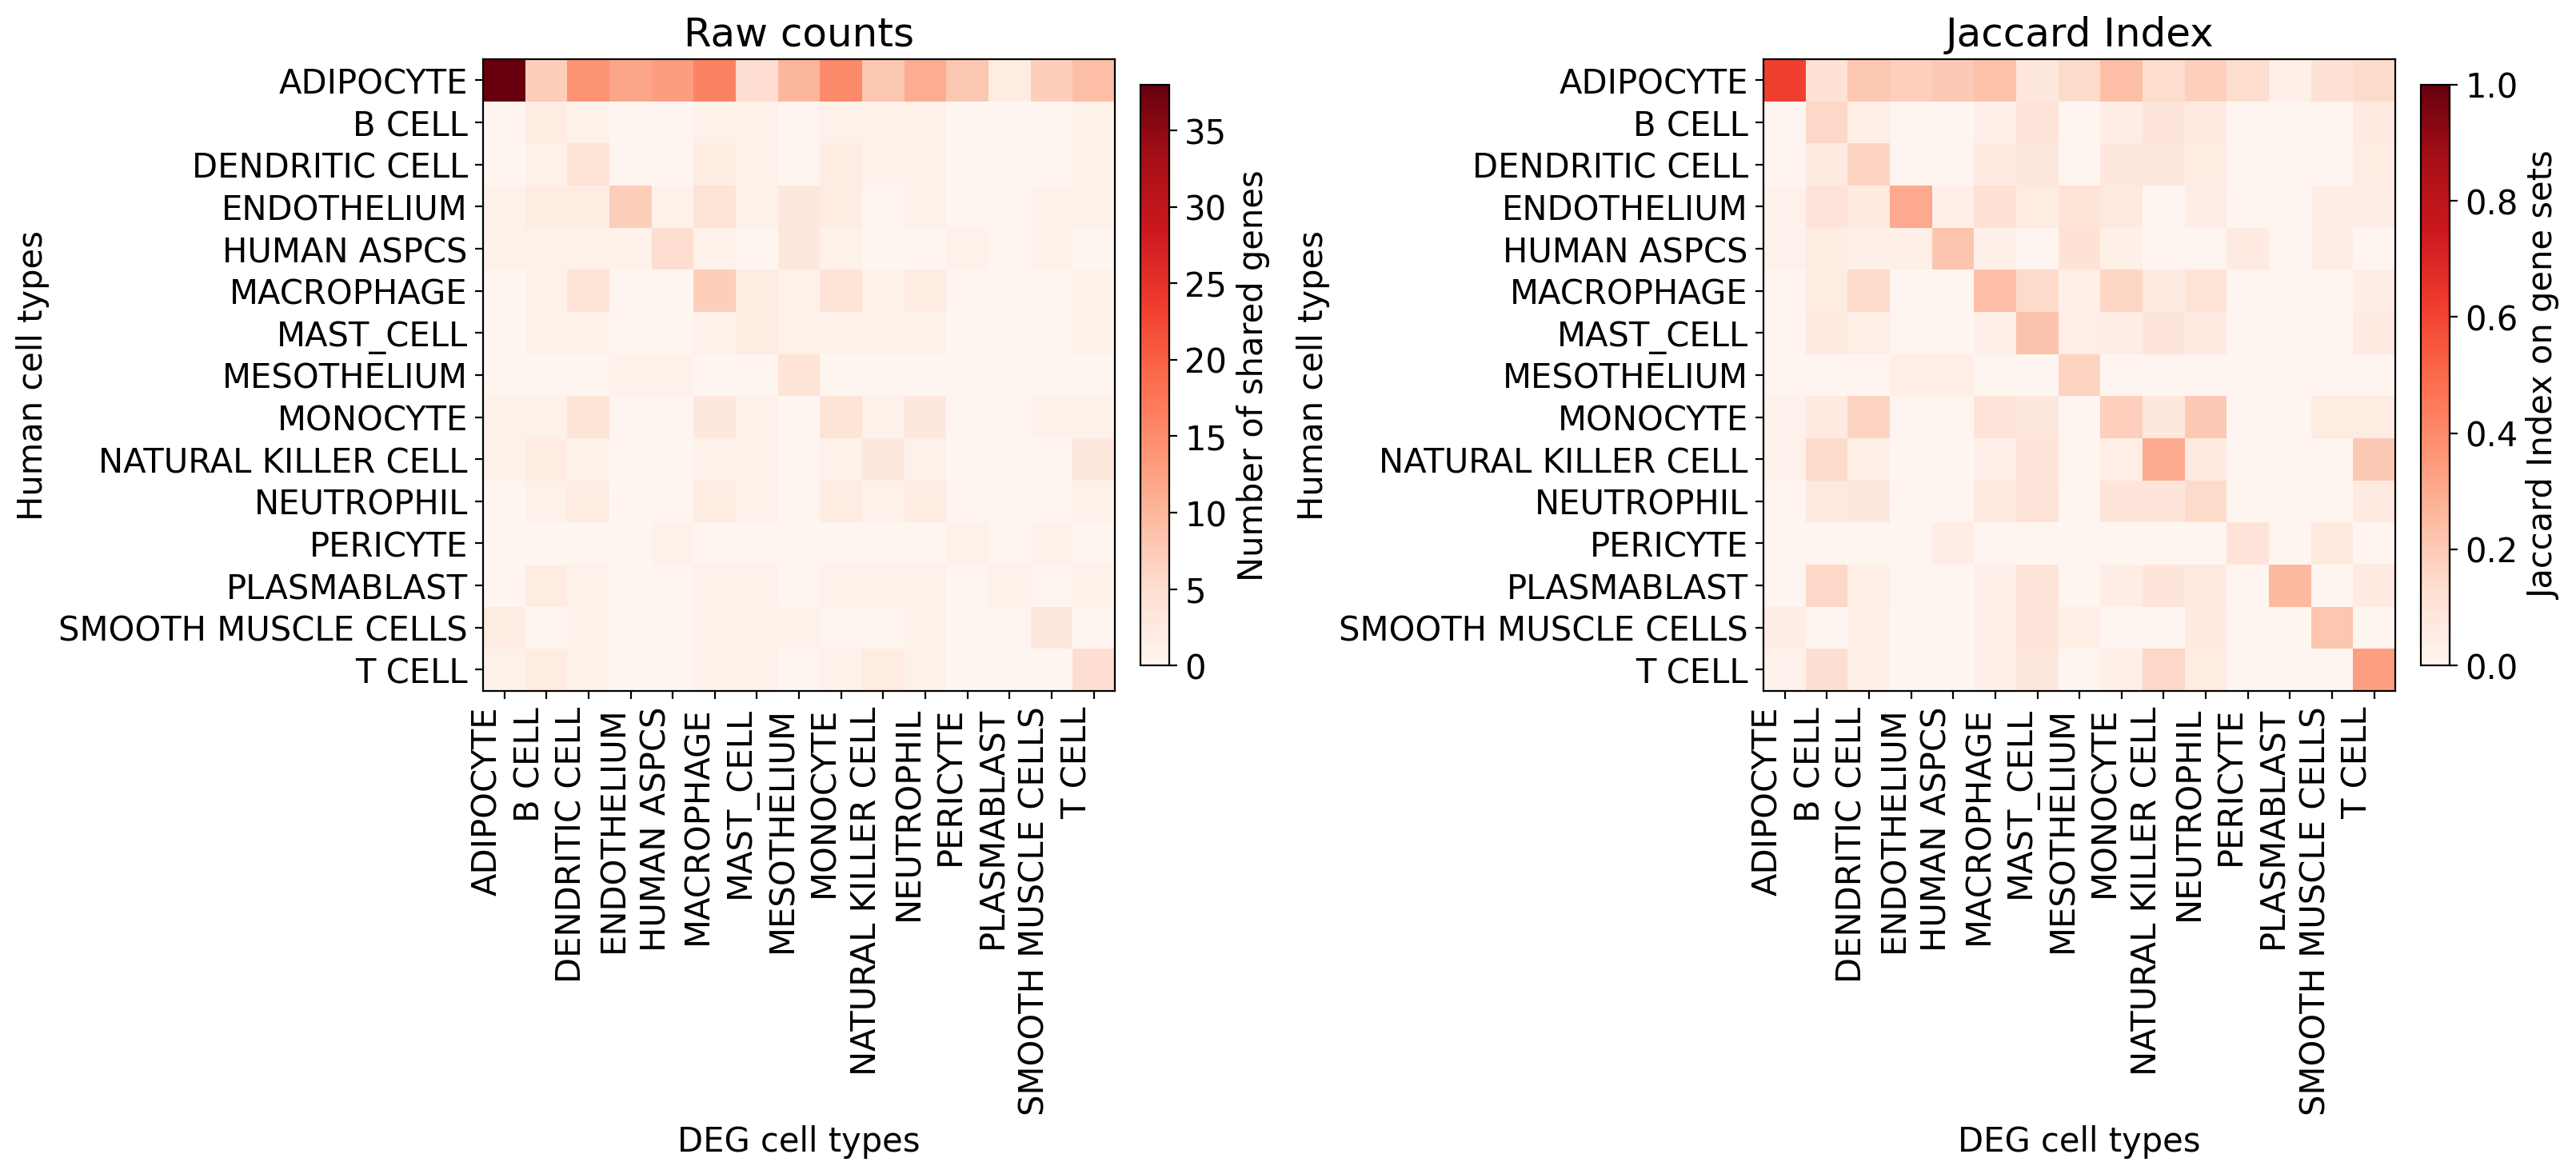

In [81]:
fig, axs = plt.subplots(figsize=(16, 8), ncols=2, constrained_layout=True)

ax = axs[0]
x = mtx[:,:,1] 
cax = ax.imshow(x, cmap="Reds")
ax.set(**{
    "xlabel": "DEG cell types",
    "ylabel": "Human cell types",
    "xticks": np.arange(len(degct)),
    "yticks": np.arange(len(hmnct)),
    "xticklabels": degct,
    "yticklabels": hmnct,
    "title": "Raw counts"
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
plt.colorbar(cax,fraction=0.046, pad=0.04, label="Number of shared genes")

ax = axs[1]
x = mtx[:,:,1] / (mtx.sum(axis=2))
cax = ax.imshow(x, cmap="Reds", vmin=0, vmax=1)
ax.set(**{
    "xlabel": "DEG cell types",
    "ylabel": "Human cell types",
    "xticks": np.arange(len(degct)),
    "yticks": np.arange(len(hmnct)),
    "xticklabels": degct,
    "yticklabels": hmnct,
    "title": "Jaccard Index"    
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
plt.colorbar(cax,fraction=0.046, pad=0.04, label="Jaccard Index on gene sets")
plt.show()


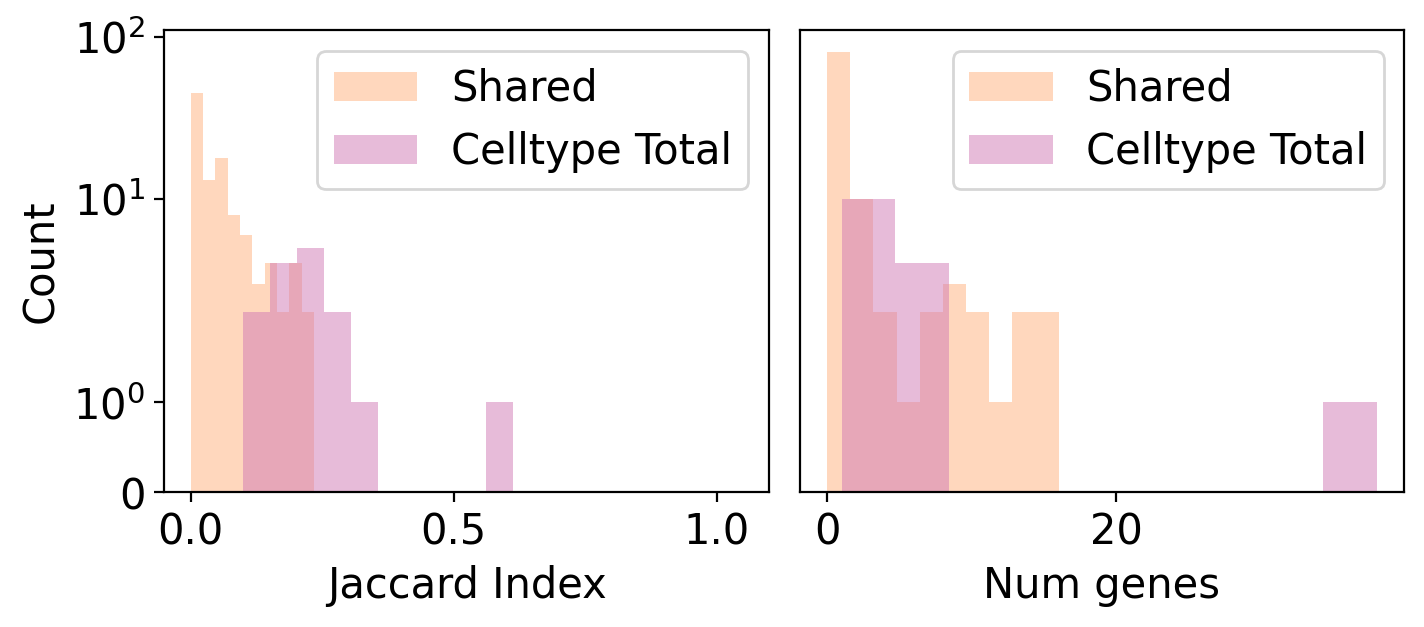

In [82]:
fig, axs = plt.subplots(figsize=(8, 3), ncols=2)
fig.subplots_adjust(hspace=0.5, wspace=0.05)
ax = axs[0]

x = mtx[:,:,1] / (mtx.sum(axis=2))
nonc = "#FFB07C"
yesc = "#D178B4"
non = x[np.triu_indices(x.shape[0], k=1)]
yes = np.diag(x)

ax.hist(non, bins = 10, alpha=0.5, label="Shared", color=nonc)
ax.hist(yes, bins = 10, alpha=0.5, label="Celltype Total", color=yesc)

ax.set(**{
    "xlabel": "Jaccard Index",
    "ylabel": "Count",
    "xlim": (-.05, 1.1),
    "yscale": "symlog"
})
ax.legend()

ax = axs[1]
ax.sharey(axs[0])
x = mtx[:,:,1]

non = x[np.triu_indices(x.shape[0], k=1)]
yes = np.diag(x)

ax.hist(non, bins = 10, alpha=0.5, label="Shared", color=nonc)
ax.hist(yes, bins = 10, alpha=0.5, label="Celltype Total", color=yesc)

ax.set(**{
    "xlabel": "Num genes",
    # "ylabel": "Count",
    # "yticks": [],
    # "yticklabels": [],
    "yscale": "symlog"
})
ax.yaxis.set_visible(False)
ax.legend()


plt.show()

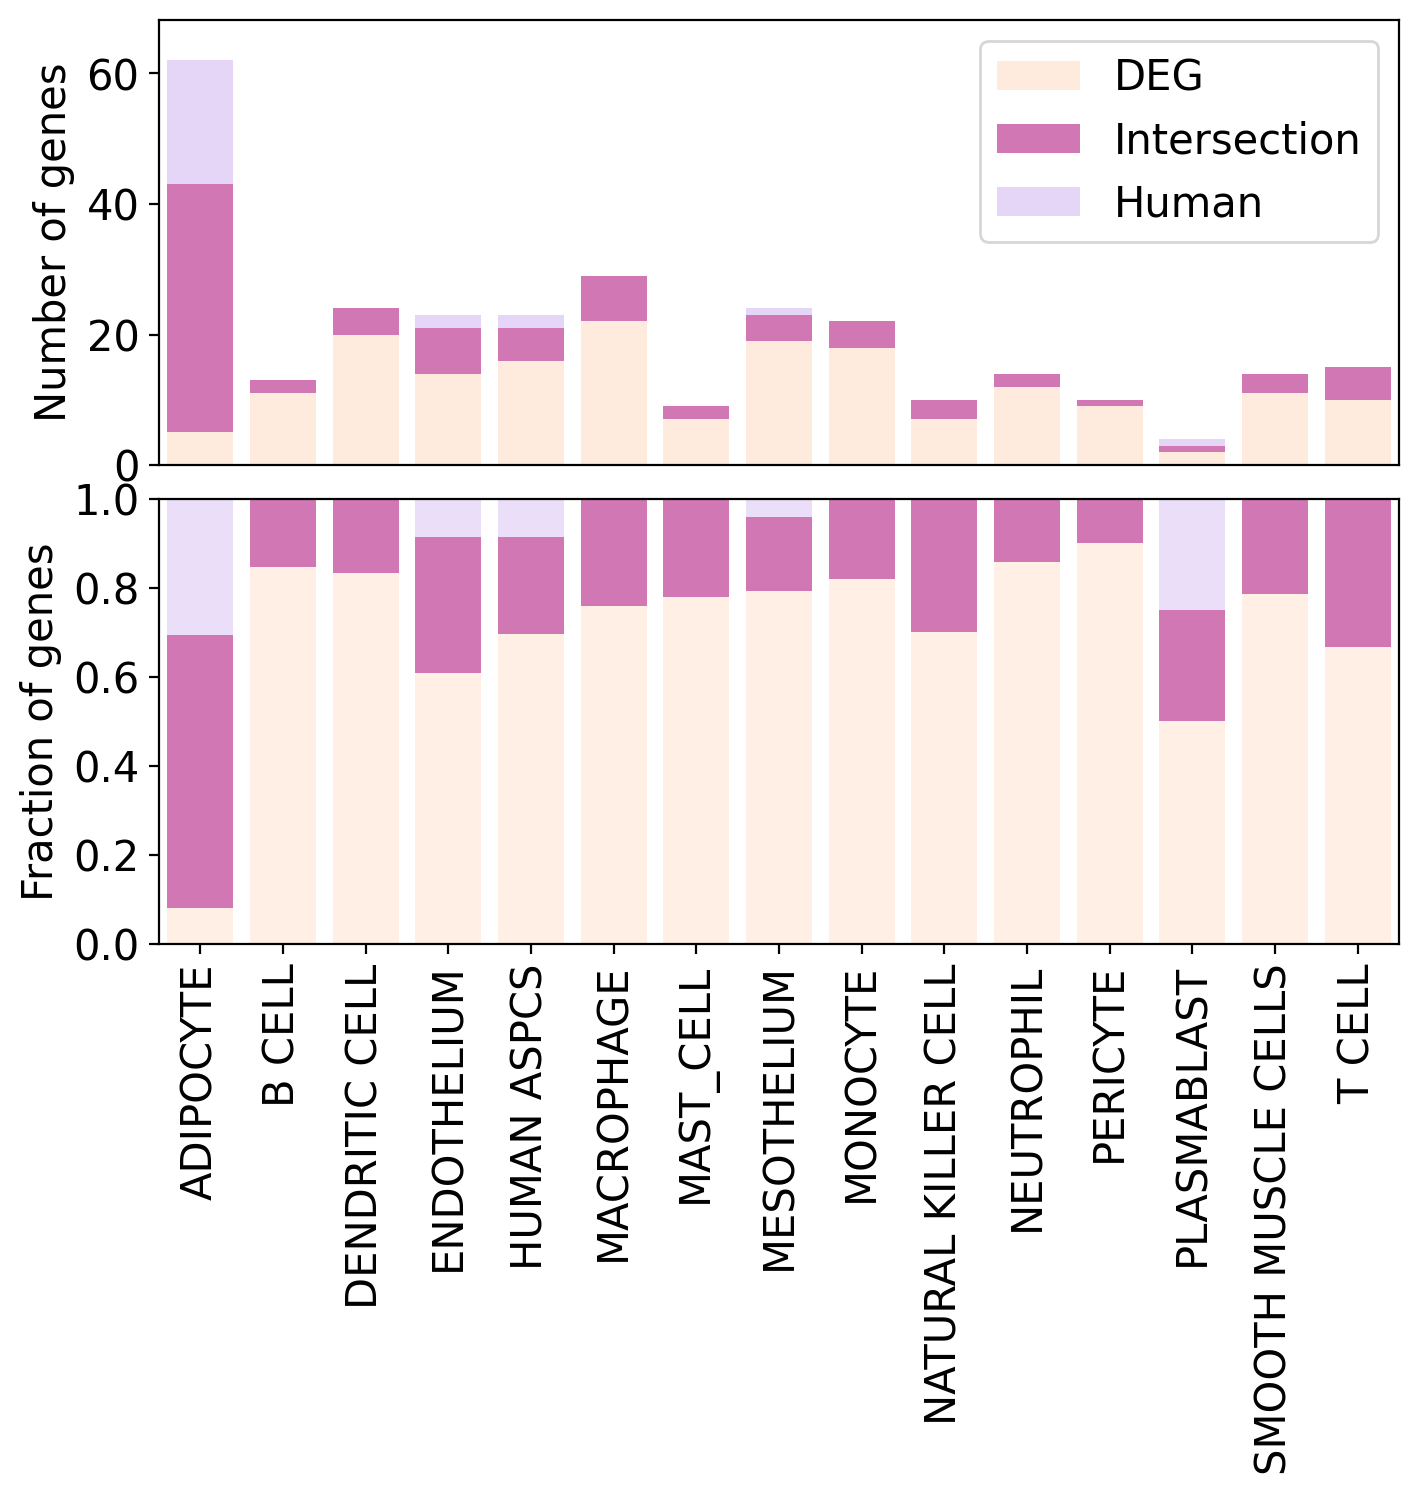

In [83]:
fig, axs = plt.subplots(figsize=(8,6), nrows=2)
fig.subplots_adjust(hspace=0.075, wspace=0.5)
ax = axs[0]
y3 = np.diag(mtx[:,:,0]) # left
y2 = np.diag(mtx[:,:,1]) # itx
y1 = np.diag(mtx[:,:,2]) # right

# left, itx, right colors
lc = "#FFB07C"
ic = "#D178B4"
rc = "#9B5DE5"

x = hmnct

ax.bar(x, y1, bottom=0,     color=lc, alpha = 0.25, label=f'DEG')
ax.bar(x, y2, bottom=y1,    color=ic, alpha = 1.0, label='Intersection')
ax.bar(x, y3, bottom=y1+y2, color=rc, alpha = 0.25, label=f'Human')

ax.set(
    **{
        "ylabel": "Number of genes",
        "xticks": np.arange(len(x)),
        "ylim": (0, 1.1 * (y1+y2+y3).max()),
        "xlim": (-0.5, len(x)-0.5)
    }
)
ax.xaxis.set_visible(False)

# ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

ax.legend()#bbox_to_anchor=(1,1))

ax = axs[1]
ax.sharex(axs[0])
y3 = np.diag(norm_mtx[:,:,0]) # left
y2 = np.diag(norm_mtx[:,:,1]) # itx
y1 = np.diag(norm_mtx[:,:,2]) # right

# left, itx, right colors
lc = "#FFB07C"
ic = "#D178B4"
rc = "#9B5DE5"

x = hmnct

ax.bar(x, y1, bottom=0,     color=lc, alpha = 0.2, label=f'DEG')
ax.bar(x, y2, bottom=y1,    color=ic, alpha = 1.0, label='Intersection')
ax.bar(x, y3, bottom=y1+y2, color=rc, alpha = 0.2, label=f'Human')

ax.set(
    **{
        "ylabel": "Fraction of genes",
        "xticks": np.arange(len(x)),
        "ylim": (0, 1),
        "xlim": (-0.5, len(x)-0.5)
    }
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

# Show the plot
plt.show()


# How do the LFC/pv compare between the consistent cell types and the inconsistent ones?

# DEG against itself

In [33]:
(mtx, norm_mtx, _, degct) = ctg_metric(deg, deg, gene_col = "feature_identifier", ct_col = "cell_type_id", df1_label="hmn", df2_label="deg", comm_ct=True, comm_gene=True)

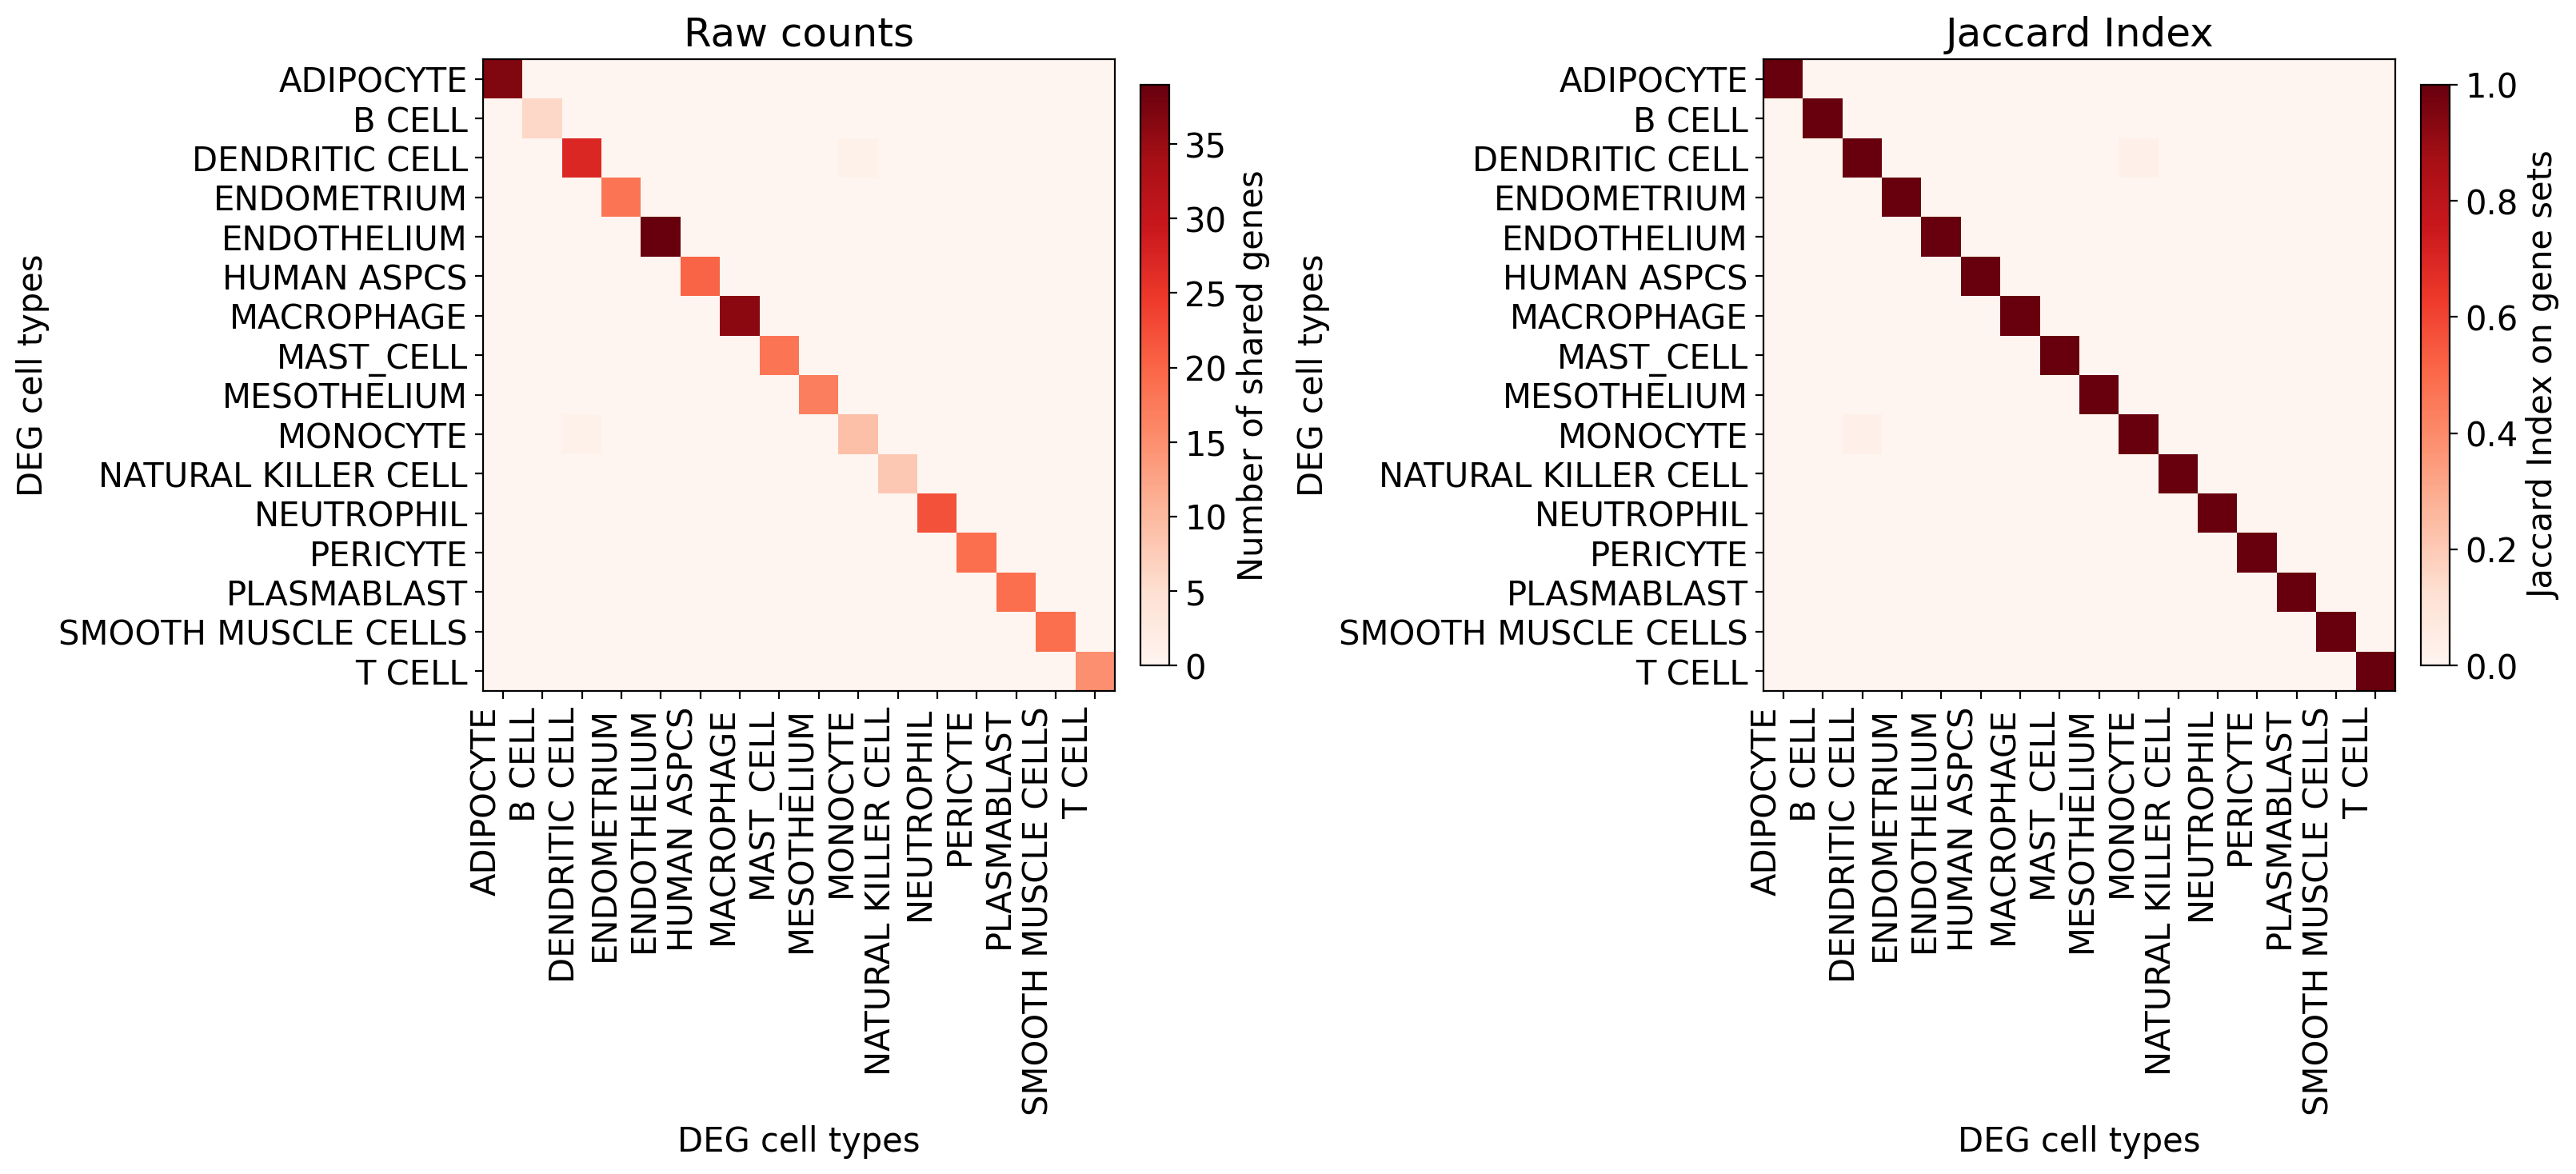

In [34]:
fig, axs = plt.subplots(figsize=(16, 8), ncols=2, constrained_layout=True)

ax = axs[0]
x = mtx[:,:,1] 
cax = ax.imshow(x, cmap="Reds")
ax.set(**{
    "xlabel": "DEG cell types",
    "ylabel": "DEG cell types",
    "xticks": np.arange(len(degct)),
    "yticks": np.arange(len(degct)),
    "xticklabels": degct,
    "yticklabels": degct,
    "title": "Raw counts"
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
plt.colorbar(cax,fraction=0.046, pad=0.04, label="Number of shared genes")

ax = axs[1]
x = mtx[:,:,1] / (mtx.sum(axis=2))
cax = ax.imshow(x, cmap="Reds")
ax.set(**{
    "xlabel": "DEG cell types",
    "ylabel": "DEG cell types",
    "xticks": np.arange(len(degct)),
    "yticks": np.arange(len(degct)),
    "xticklabels": degct,
    "yticklabels": degct,
    "title": "Jaccard Index"    
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
plt.colorbar(cax,fraction=0.046, pad=0.04, label="Jaccard Index on gene sets")
plt.show()


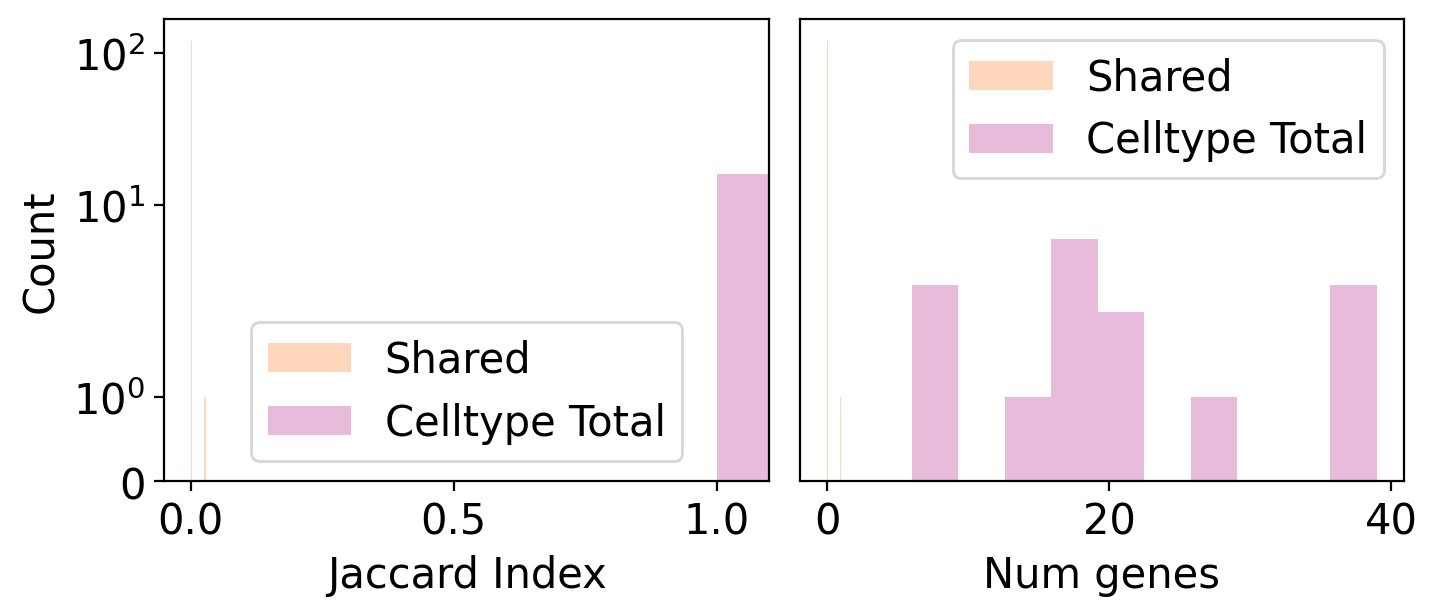

In [35]:
fig, axs = plt.subplots(figsize=(8, 3), ncols=2)
fig.subplots_adjust(hspace=0.5, wspace=0.05)
ax = axs[0]

x = mtx[:,:,1] / (mtx.sum(axis=2))
nonc = "#FFB07C"
yesc = "#D178B4"
non = x[np.triu_indices(x.shape[0], k=1)]
yes = np.diag(x)

ax.hist(non, bins = 10, alpha=0.5, label="Shared", color=nonc)
ax.hist(yes, bins = 10, alpha=0.5, label="Celltype Total", color=yesc)

ax.set(**{
    "xlabel": "Jaccard Index",
    "ylabel": "Count",
    "xlim": (-.05, 1.1),
    "yscale": "symlog"
})
ax.legend()

ax = axs[1]
ax.sharey(axs[0])
x = mtx[:,:,1]

non = x[np.triu_indices(x.shape[0], k=1)]
yes = np.diag(x)

ax.hist(non, bins = 10, alpha=0.5, label="Shared", color=nonc)
ax.hist(yes, bins = 10, alpha=0.5, label="Celltype Total", color=yesc)

ax.set(**{
    "xlabel": "Num genes",
    # "ylabel": "Count",
    # "yticks": [],
    # "yticklabels": [],
    "yscale": "symlog"
})
ax.yaxis.set_visible(False)
ax.legend()


plt.show()

# Human against itself

In [36]:
(mtx, norm_mtx, hmnct, _) = ctg_metric(hmn, hmn, gene_col = "feature_identifier", ct_col = "cell_type_id", df1_label="hmn", df2_label="deg", comm_ct=True, comm_gene=True)

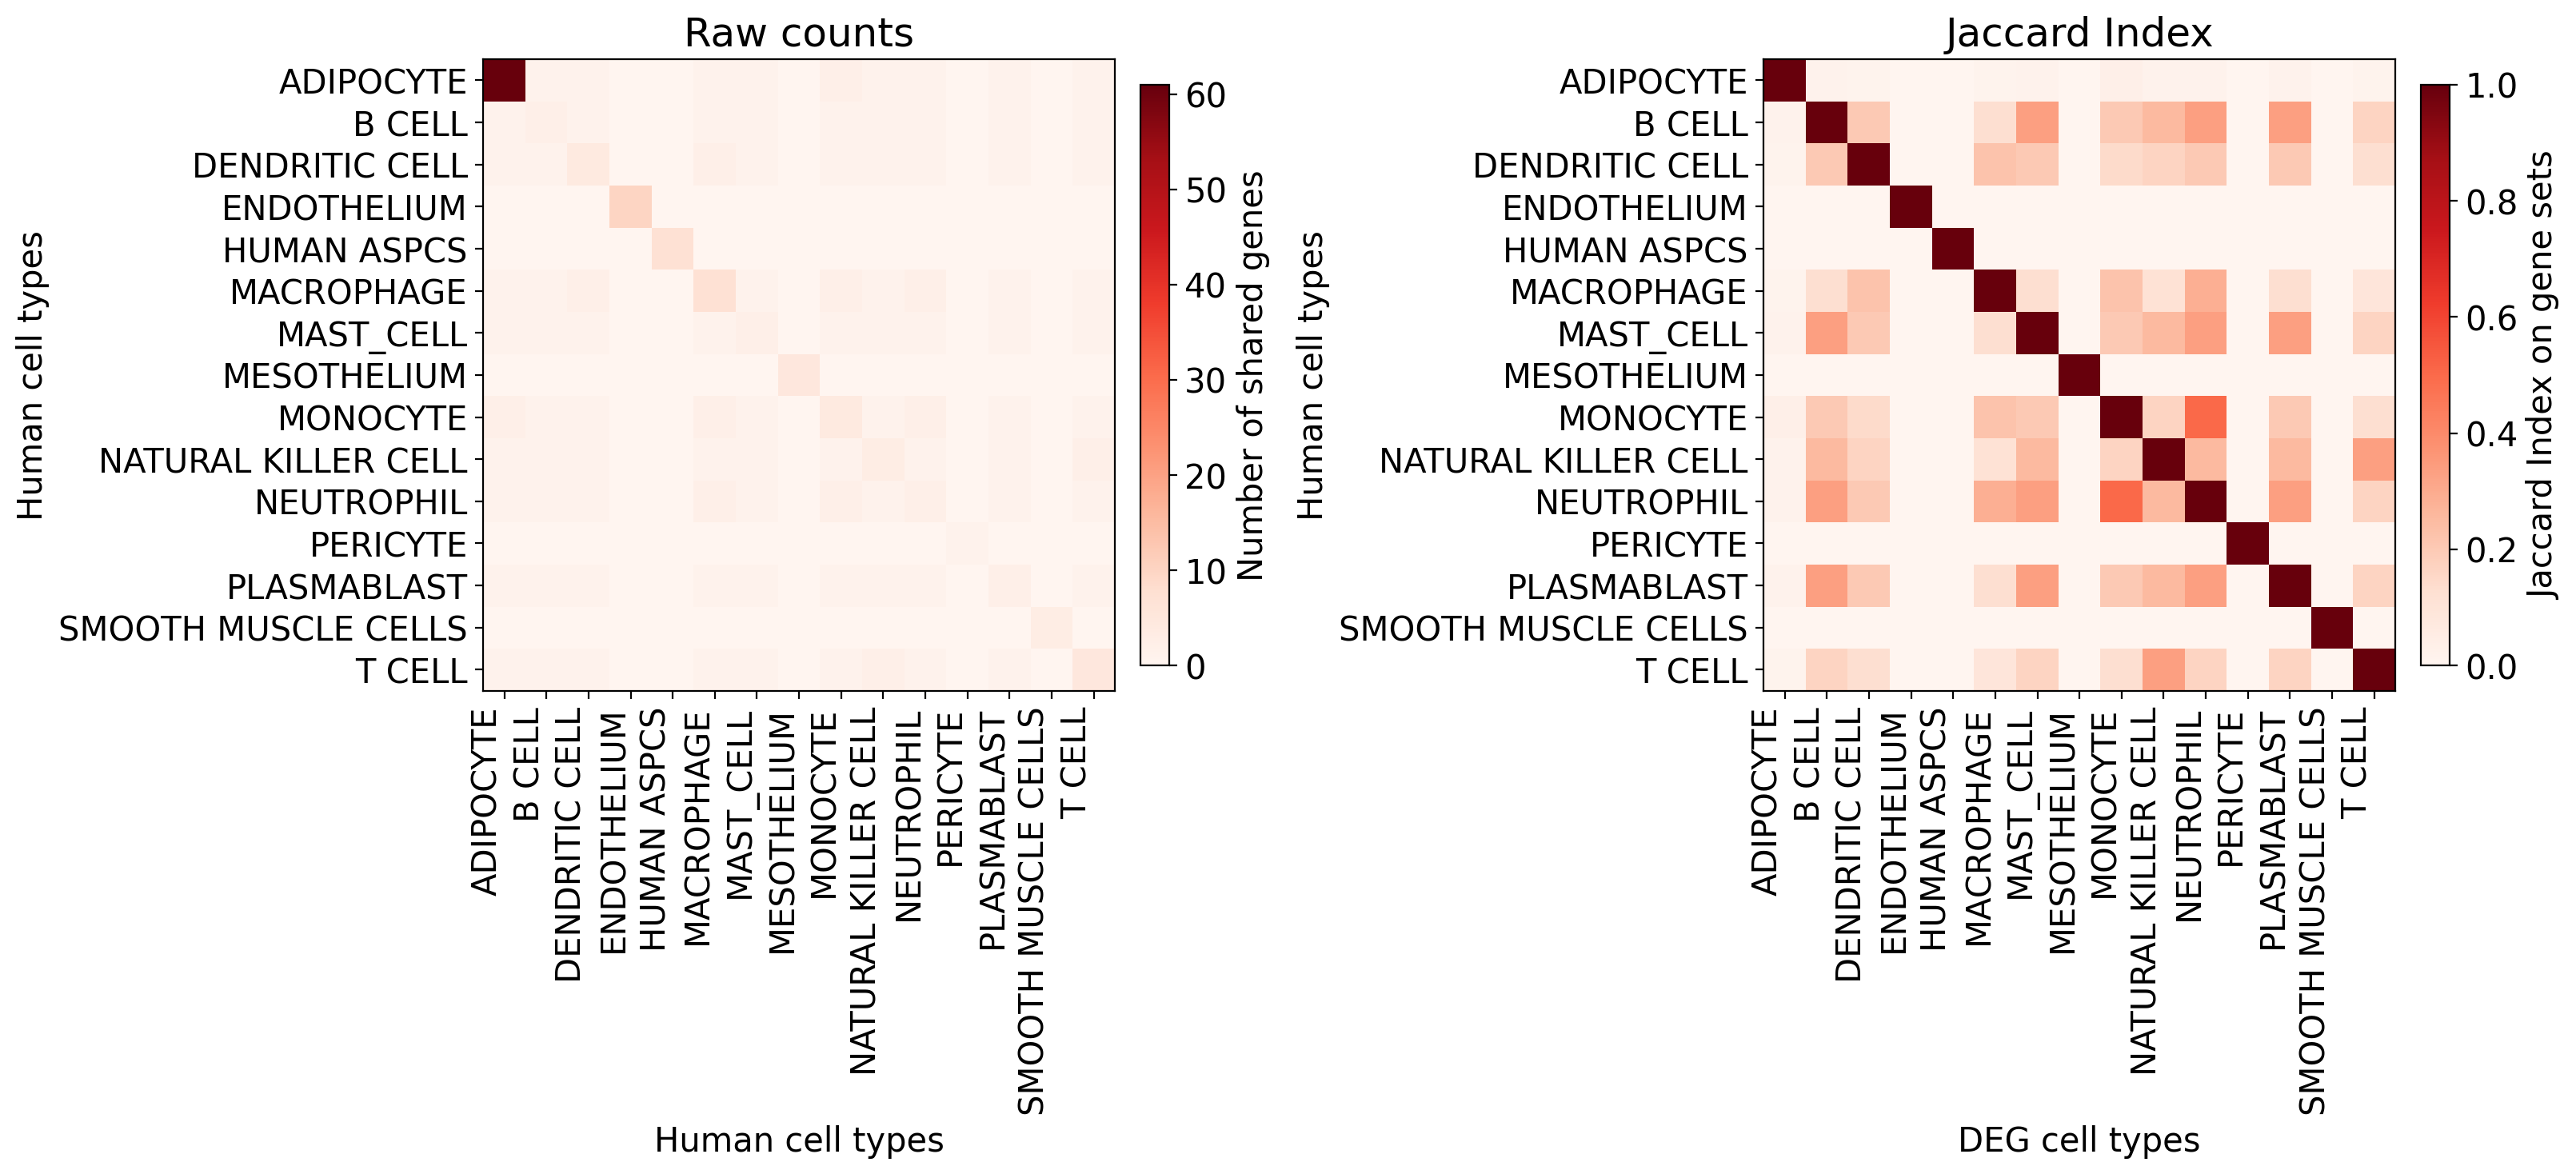

In [37]:
fig, axs = plt.subplots(figsize=(16, 8), ncols=2, constrained_layout=True)

ax = axs[0]
x = mtx[:,:,1] 
cax = ax.imshow(x, cmap="Reds")
ax.set(**{
    "xlabel": "Human cell types",
    "ylabel": "Human cell types",
    "xticks": np.arange(len(hmnct)),
    "yticks": np.arange(len(hmnct)),
    "xticklabels": hmnct,
    "yticklabels": hmnct,
    "title": "Raw counts"
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
plt.colorbar(cax,fraction=0.046, pad=0.04, label="Number of shared genes")

ax = axs[1]
x = mtx[:,:,1] / (mtx.sum(axis=2))
cax = ax.imshow(x, cmap="Reds")
ax.set(**{
    "xlabel": "DEG cell types",
    "ylabel": "Human cell types",
    "xticks": np.arange(len(hmnct)),
    "yticks": np.arange(len(hmnct)),
    "xticklabels": hmnct,
    "yticklabels": hmnct,
    "title": "Jaccard Index"    
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
plt.colorbar(cax,fraction=0.046, pad=0.04, label="Jaccard Index on gene sets")
plt.show()


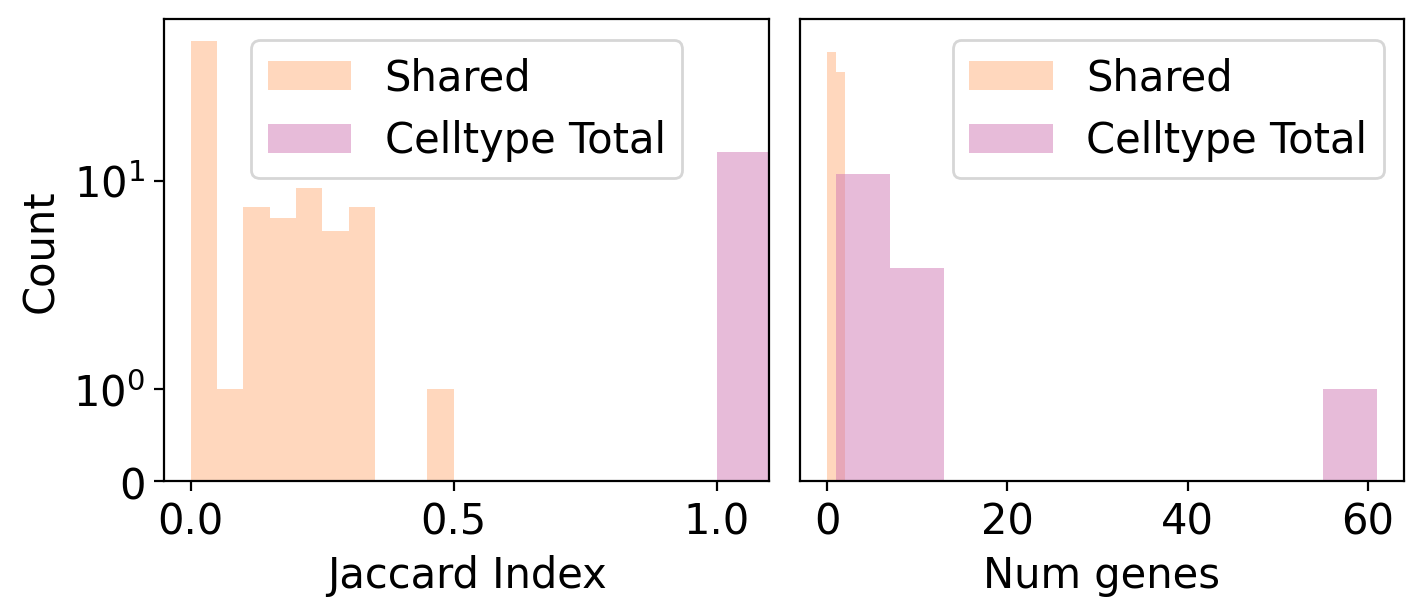

In [38]:
fig, axs = plt.subplots(figsize=(8, 3), ncols=2)
fig.subplots_adjust(hspace=0.5, wspace=0.05)
ax = axs[0]

x = mtx[:,:,1] / (mtx.sum(axis=2))
nonc = "#FFB07C"
yesc = "#D178B4"
non = x[np.triu_indices(x.shape[0], k=1)]
yes = np.diag(x)

ax.hist(non, bins = 10, alpha=0.5, label="Shared", color=nonc)
ax.hist(yes, bins = 10, alpha=0.5, label="Celltype Total", color=yesc)

ax.set(**{
    "xlabel": "Jaccard Index",
    "ylabel": "Count",
    "xlim": (-.05, 1.1),
    "yscale": "symlog"
})
ax.legend()

ax = axs[1]
ax.sharey(axs[0])
x = mtx[:,:,1]

non = x[np.triu_indices(x.shape[0], k=1)]
yes = np.diag(x)

ax.hist(non, bins = 2, alpha=0.5, label="Shared", color=nonc)
ax.hist(yes, bins = 10, alpha=0.5, label="Celltype Total", color=yesc)

ax.set(**{
    "xlabel": "Num genes",
    # "ylabel": "Count",
    # "yticks": [],
    # "yticklabels": [],
    "yscale": "symlog"
})
ax.yaxis.set_visible(False)
ax.legend()


plt.show()

## Ternary Plots

In [39]:
norm_mtx.shape

(15, 15, 3)

In [40]:
tmp = norm_mtx[np.eye(norm_mtx.shape[0], dtype=bool)]
l = tmp[:,0]
x = tmp[:,1]
r = tmp[:,2]

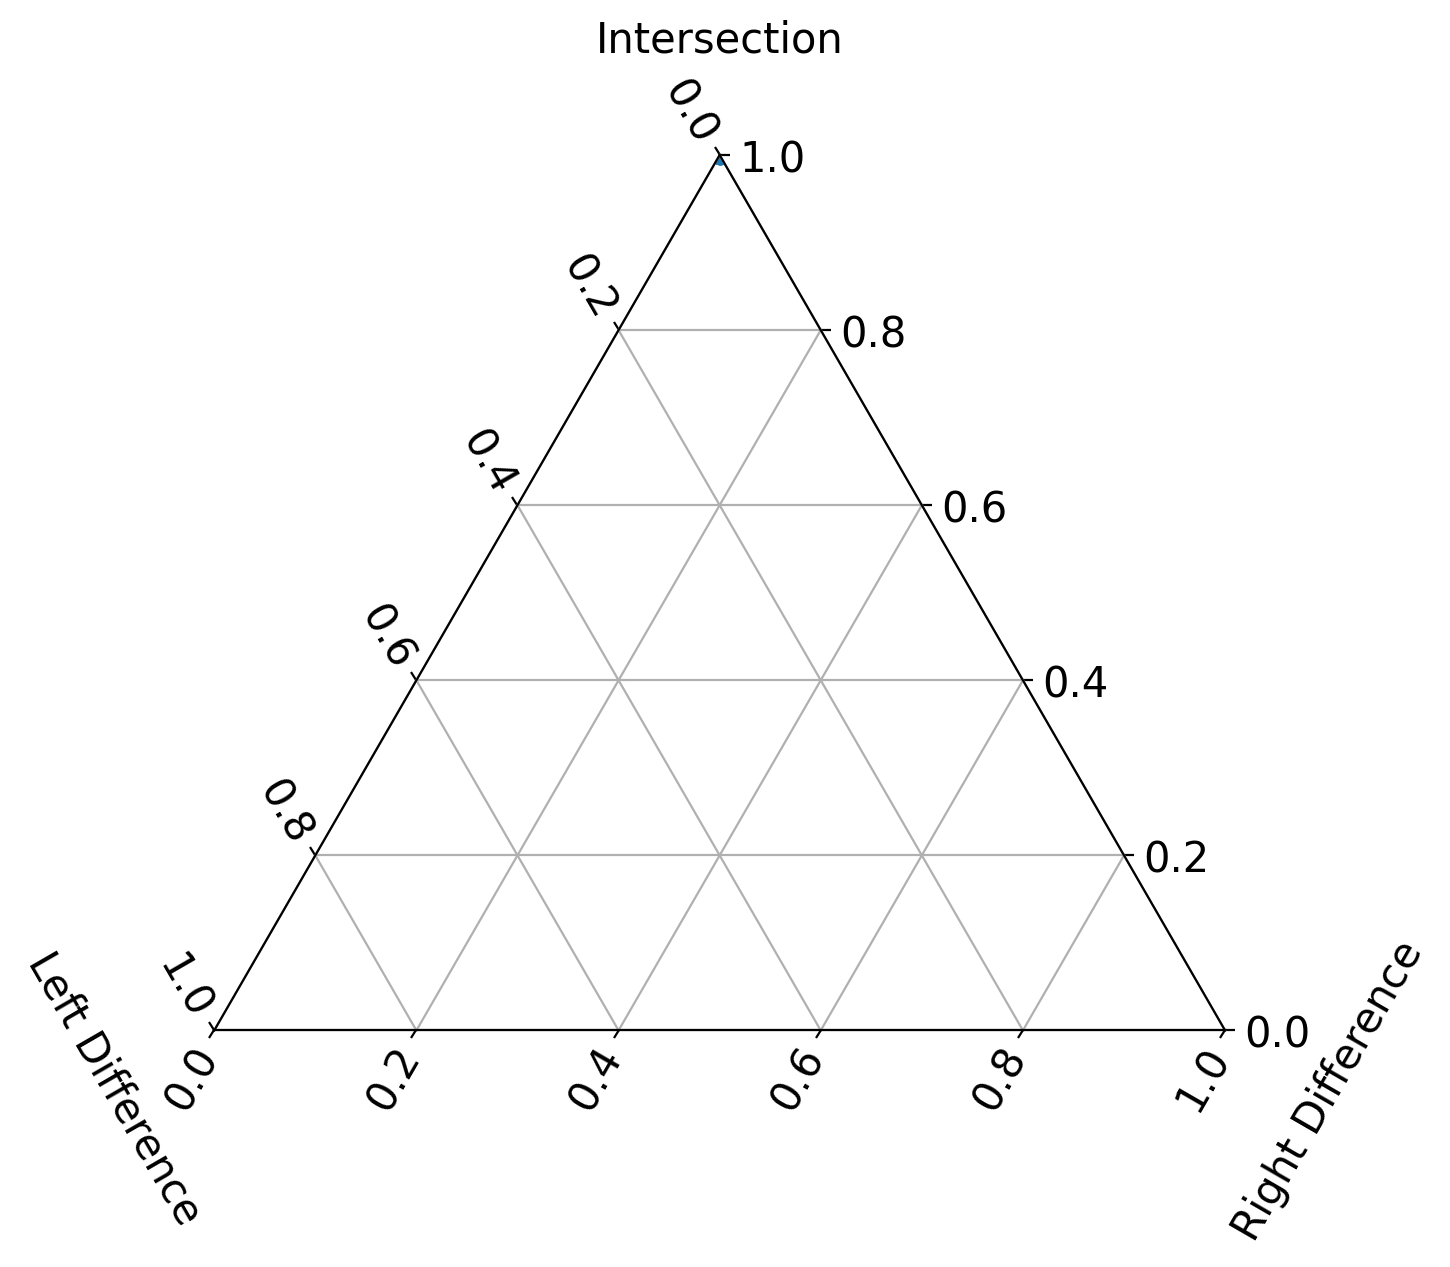

In [41]:
fig = plt.figure(figsize=(15, 15))
fig.subplots_adjust(left=0.075, right=0.85, wspace=0.3)

ax = fig.add_subplot(1, 2, 1, projection="ternary")
pc = ax.scatter(x, l, r, alpha = 0.6, label = f"") # top, left, right

ax.grid(visible=  True, axis = 'both')

ax.set_tlabel('Intersection')
ax.set_llabel('Left Difference')
ax.set_rlabel('Right Difference')

#ax.legend(title = "Gene Expression Set Operations with Same Cell Type Control", fontsize = 'small', bbox_to_anchor=(0, 1, 0, .102))

plt.show()